In [13]:
# ============================================
# LIBRERÍAS A USAR
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy.stats as stats

#### 1. Inspección inicial 

In [1]:
# Cargar el dataset

data = pd.read_excel(r"datos_regresion_casas.xlsx")

NameError: name 'pd' is not defined

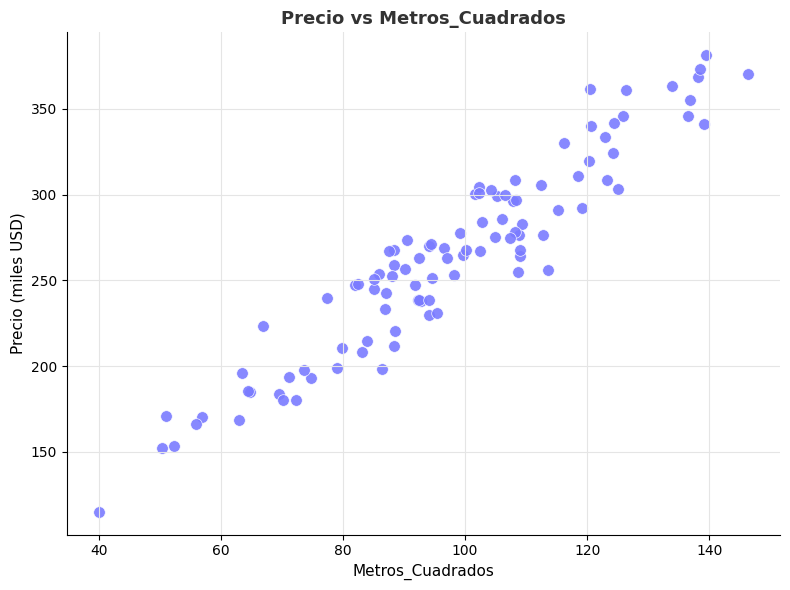

In [15]:
# VISUALIZACIONES

# Scatterplot: Metros_Cuadrados vs Precio
plt.figure(figsize=(8, 6))
plt.scatter(
    data["Metros_Cuadrados"],
    data["Precio_Miles_USD"],
    color="#7a7bff",
    edgecolor="white",
    linewidth=0.5,
    s=70,
    alpha=0.9,
)
plt.xlabel("Metros_Cuadrados", fontsize=11)
plt.ylabel("Precio (miles USD)", fontsize=11)
plt.title("Precio vs Metros_Cuadrados", fontsize=13, fontweight="bold", color="#333333")
plt.grid(color="#e5e5e5", linestyle="-", linewidth=0.8)
plt.gca().set_facecolor("white")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

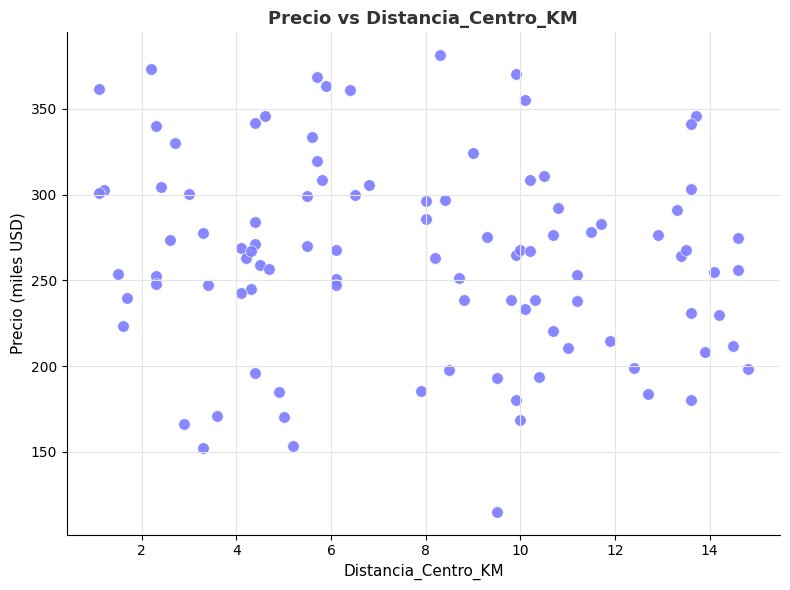

In [16]:
# Scatterplot: Distancia_Centro_KM vs Precio
plt.figure(figsize=(8, 6))
plt.scatter(
    data["Distancia_Centro_KM"],
    data["Precio_Miles_USD"],
    color="#7a7bff",
    edgecolor="white",
    linewidth=0.5,
    s=70,
    alpha=0.9,
)
plt.xlabel("Distancia_Centro_KM", fontsize=11)
plt.ylabel("Precio (miles USD)", fontsize=11)
plt.title("Precio vs Distancia_Centro_KM", fontsize=13, fontweight="bold", color="#333333")
plt.grid(color="#e5e5e5", linestyle="-", linewidth=0.8)
plt.gca().set_facecolor("white")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

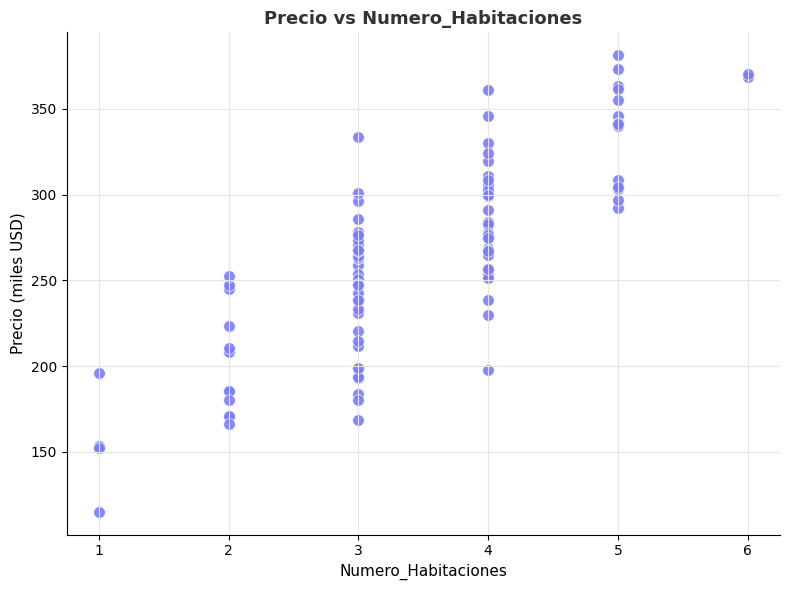

In [17]:
# Scatterplot: Numero_Habitaciones vs Precio
plt.figure(figsize=(8, 6))
plt.scatter(
    data["Numero_Habitaciones"],
    data["Precio_Miles_USD"],
    color="#7a7bff",
    edgecolor="white",
    linewidth=0.5,
    s=70,
    alpha=0.9,
)
plt.xlabel("Numero_Habitaciones", fontsize=11)
plt.ylabel("Precio (miles USD)", fontsize=11)
plt.title("Precio vs Numero_Habitaciones", fontsize=13, fontweight="bold", color="#333333")
plt.grid(color="#e5e5e5", linestyle="-", linewidth=0.8)
plt.gca().set_facecolor("white")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

# Construcción del modelo de regresión

In [18]:



modelo_simple = ols('Precio_Miles_USD ~ Metros_Cuadrados', data=data).fit()


In [19]:
#Mostrar resultados de la modelizacion

# Mostrar resultados de la modelizacion

print("\n--- RESUMEN DEL MODELO ---")
print(modelo_simple.summary().tables[1])
print("R2:", round(modelo_simple.rsquared, 4))
print("R2-ajustado:", round(modelo_simple.rsquared_adj, 4))


--- RESUMEN DEL MODELO ---
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           29.4315      8.127      3.621      0.000      13.304      45.559
Metros_Cuadrados     2.4022      0.081     29.562      0.000       2.241       2.563
R2: 0.8992
R2-ajustado: 0.8981


In [20]:
# Obtener las predecciones del modelo

valores_predichos= modelo_simple.fittedvalues

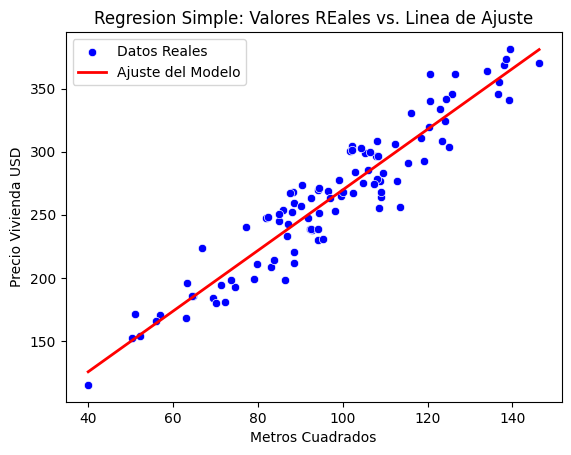

In [21]:
# Calcular los valores que el modelo predice para cada vivienda del dataset
valores_predichos = modelo_simple.fittedvalues


# Visualizar
sns.scatterplot(x=data['Metros_Cuadrados'], y=data['Precio_Miles_USD'], color='blue', label='Datos Reales')
sns.lineplot(x=data['Metros_Cuadrados'], y=valores_predichos, color='red', linewidth=2, label='Ajuste del Modelo')
plt.title("Regresion Simple: Valores REales vs. Linea de Ajuste")
plt.xlabel('Metros Cuadrados')
plt.ylabel('Precio Vivienda USD')
plt.legend()
plt.show()

## Otra forma de hacer la regresión

In [26]:
# Definimos los datos a utilizar

x = data['Metros_Cuadrados']
y = data['Precio_Miles_USD']

# Añadimos la cte, es decir, el intercepto (beta 0)

x_con_constante = sm.add_constant(x)

# Entrenamos el modelo

modelo_simple_V2 = sm.OLS(y, x_con_constante).fit()

In [27]:
# Mostrar resultados

print(modelo_simple_V2.summary())

                            OLS Regression Results                            
Dep. Variable:       Precio_Miles_USD   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.898
Method:                 Least Squares   F-statistic:                     873.9
Date:                Mon, 29 Jun 2026   Prob (F-statistic):           1.27e-50
Time:                        16:09:03   Log-Likelihood:                -431.23
No. Observations:                 100   AIC:                             866.5
Df Residuals:                      98   BIC:                             871.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               29.4315      8.127  

In [ ]:
## Ahora con las 3 viariables

print("CASO 2 Regresión Multiple sin colinealidad")

modelo_multiple = ols('Precio_Miles_USD ~ Metros_Cuadrados + Distancia_Centro_KM', data=data).fit()

# Mostrar resultados de la modelizacion

print("\n--- RESUMEN DEL MODELO ---")
print(modelo_multiple.summary().tables[1])
print("R2:", round(modelo_multiple.rsquared, 4))
print("R2-ajustado:", round(modelo_multiple.rsquared_adj, 4))


CASO 2 Regresión Multipkke sin colinealidad

--- RESUMEN DEL MODELO ---
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              51.8075      3.781     13.701      0.000      44.303      59.312
Metros_Cuadrados        2.4985      0.036     68.579      0.000       2.426       2.571
Distancia_Centro_KM    -4.0675      0.204    -19.981      0.000      -4.472      -3.663
R2: 0.9803
R2-ajustado: 0.9799


In [37]:
# Calcular VIF

print("\n--- FACTOR DE INFLACION DE LA VARIANZA (VIF) ---")
matriz_x_sin = modelo_multiple.model.exog
for i in range(1, matriz_x_sin.shape[1]):
    vif = variance_inflation_factor(matriz_x_sin, i)
    print("Variable", modelo_multiple.model.exog_names[i], ": VIF =", round(vif, 2))


--- FACTOR DE INFLACION DE LA VARIANZA (VIF) ---
Variable Metros_Cuadrados : VIF = 3.69
Variable Distancia_Centro_KM : VIF = 1.02
Variable Numero_Habitaciones : VIF = 3.67


In [46]:
# Calcular el determinante de la matriz de correlación

X = data[['Metros_Cuadrados', 'Distancia_Centro_KM', 'Numero_Habitaciones']]
matriz_corre = X.corr()

determinante = np.linalg.det(matriz_corre)
print(round(determinante, 4))

if determinante < 0.01:
    print("Existe fuerte evidencia de multicolinealidad")
elif determinante < 0.1:
    print("Existe cierta multicolinealidad")
else:
    print("No se observan problemas importantes de multicolinealidad")
    



0.2679
No se observan problemas importantes de multicolinealidad


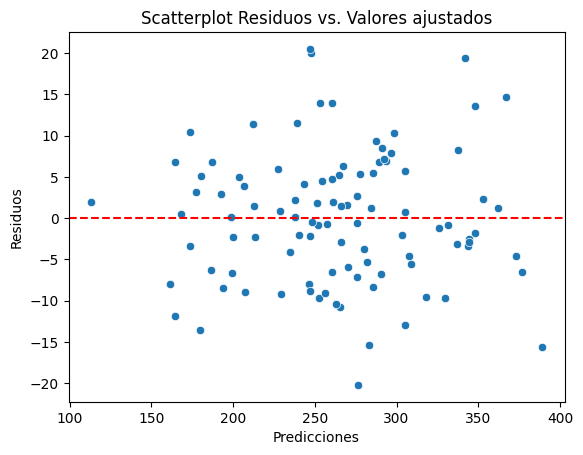

In [48]:
# Visualización

valores_ajustados_2 = modelo_multiple.fittedvalues
residuos_2 = modelo_multiple.resid

# Gráfico de residuos

sns.scatterplot(x=valores_ajustados_2, y=residuos_2)
plt.axhline(y=0, color="red", linestyle="--", linewidth=1.5)
plt.title("Scatterplot Residuos vs. Valores ajustados")
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.show()

### CASO 1 - Regresión simple


--- FACTOR DE INFLACION DE LA VARIANZA (VIF) ---
Variable Metros_Cuadrados : VIF = 1.02
Variable Distancia_Centro_KM : VIF = 1.02

Determinante: 0.9825
No se observan problemas importantes de multicolinealidad


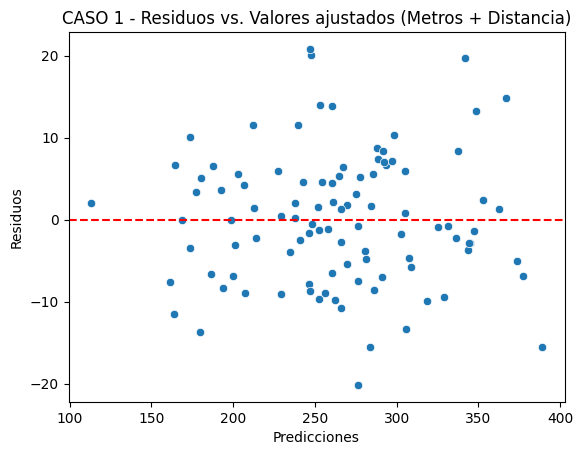

In [52]:
# ====================================================
# CASO 1: Metros_Cuadrados + Distancia_Centro_KM (2 variables)
# ====================================================

modelo_caso1 = ols(
    "Precio_Miles_USD ~ Metros_Cuadrados + Distancia_Centro_KM",
    data=data,
).fit()

# Calcular VIF
print("\n--- FACTOR DE INFLACION DE LA VARIANZA (VIF) ---")
matriz_x_1 = modelo_caso1.model.exog
for i in range(1, matriz_x_1.shape[1]):
    vif = variance_inflation_factor(matriz_x_1, i)
    print("Variable", modelo_caso1.model.exog_names[i], ": VIF =", round(vif, 2))

# Calcular el determinante de la matriz de correlación
X1 = data[["Metros_Cuadrados", "Distancia_Centro_KM"]]
matriz_corre_1 = X1.corr()
determinante_1 = np.linalg.det(matriz_corre_1)
print("\nDeterminante:", round(determinante_1, 4))

if determinante_1 < 0.01:
    print("Existe fuerte evidencia de multicolinealidad")
elif determinante_1 < 0.1:
    print("Existe cierta multicolinealidad")
else:
    print("No se observan problemas importantes de multicolinealidad")

# Grafico de residuos
valores_ajustados_1 = modelo_caso1.fittedvalues
residuos_1 = modelo_caso1.resid

sns.scatterplot(x=valores_ajustados_1, y=residuos_1)
plt.axhline(y=0, color="red", linestyle="--", linewidth=1.5)
plt.title("CASO 1 - Residuos vs. Valores ajustados (Metros + Distancia)")
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.show()


## CASO 2 - REGRESIÓN MÚLTIPLE 

In [1]:
# Calcular VIF

print("\n--- FACTOR DE INFLACION DE LA VARIANZA (VIF) ---")
matriz_x_sin = modelo_multiple.model.exog
for i in range(1, matriz_x_sin.shape[1]):
    vif = variance_inflation_factor(matriz_x_sin, i)
    print("Variable", modelo_multiple.model.exog_names[i], ": VIF =", round(vif, 2))

# Calcular el determinante de la matriz de correlación

X = data[["Metros_Cuadrados", "Distancia_Centro_KM", "Numero_Habitaciones"]]
matriz_corre = X.corr()

determinante = np.linalg.det(matriz_corre)
print(round(determinante, 4))

if determinante < 0.01:
    print("Existe fuerte evidencia de multicolinealidad")
elif determinante < 0.1:
    print("Existe cierta multicolinealidad")
else:
    print("No se observan problemas importantes de multicolinealidad")

# Visualización

valores_ajustados_2 = modelo_multiple.fittedvalues
residuos_2 = modelo_multiple.resid

sns.scatterplot(x=valores_ajustados_2, y=residuos_2)
plt.axhline(y=0, color="red", linestyle="--", linewidth=1.5)
plt.title("Scatterplot Residuos vs. Valores ajustados")
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.show()


--- FACTOR DE INFLACION DE LA VARIANZA (VIF) ---


NameError: name 'modelo_multiple' is not defined